#  House Price Prediction - Machine Learning Project
**Dataset:** Housing Prices Dataset (Kaggle)  
**Tools:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn


## I. Project Overview

**Objective:**  
Build a regression model that predicts house prices based on property features such as area, number of rooms, amenities, and location. Identify which features most strongly influence price and provide actionable business recommendations.

**Project Workflow:**
1. Data Loading & Exploration  
2. Data Cleaning & Preprocessing  
3. Model Building & Evaluation (Linear Regression + Random Forest)  
4. Data Visualization (3 charts)  
5. Insights & Business Recommendations


## II. Importing Required Libraries

In [25]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Utilities
import os
import warnings
warnings.filterwarnings("ignore")

# Create charts directory for saving plots
os.makedirs("charts", exist_ok=True)

print(" All libraries imported successfully.")
print(f"   Pandas version    : {pd.__version__}")
print(f"   NumPy version     : {np.__version__}")

 All libraries imported successfully.
   Pandas version    : 2.2.2
   NumPy version     : 2.0.2


## Task 1 - Data Loading & Exploration


### 1.1 Load the Dataset

In [26]:
# Load the CSV dataset
df = pd.read_csv("Housing.csv")
print(f" Dataset loaded successfully - {df.shape[0]} rows × {df.shape[1]} columns")

 Dataset loaded successfully - 545 rows × 13 columns


### 1.2 First 10 Rows

In [27]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### 1.3 Dataset Shape & Structure

In [28]:
print("─" * 40)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print("─" * 40)
df.info()

────────────────────────────────────────
  Rows    : 545
  Columns : 13
────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


### 1.4 Identify Target Variable & Feature Variables

In [29]:
target_col = "price"
feature_cols = [col for col in df.columns if col != target_col]

print(" Target Variable  :", target_col)
print()
print(" Feature Variables:")
for i, col in enumerate(feature_cols, 1):
    dtype = str(df[col].dtype)
    print(f"   {i:2}. {col:<22} ({dtype})")

 Target Variable  : price

 Feature Variables:
    1. area                   (int64)
    2. bedrooms               (int64)
    3. bathrooms              (int64)
    4. stories                (int64)
    5. mainroad               (object)
    6. guestroom              (object)
    7. basement               (object)
    8. hotwaterheating        (object)
    9. airconditioning        (object)
   10. parking                (int64)
   11. prefarea               (object)
   12. furnishingstatus       (object)


### 1.5 Check for Missing Values

In [30]:
missing = df.isnull().sum()
print("Missing Values per Column:")
print("─" * 35)
print(missing.to_string())
print("─" * 35)
print(f"Total missing values : {missing.sum()}")
print()
if missing.sum() == 0:
    print(" No missing values found - dataset is complete.")
else:
    print("  Missing values detected - will handle in Task 2.")

Missing Values per Column:
───────────────────────────────────
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
───────────────────────────────────
Total missing values : 0

 No missing values found - dataset is complete.


### 1.6 Basic Statistical Summary

In [31]:
df.describe().round(2)

,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


## Task 2 - Data Cleaning & Preprocessing


### 2.1 Remove Duplicate Rows

In [32]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Rows before : {before}")
print(f"Rows after  : {after}")
print(f"Duplicates removed : {before - after}")

Rows before : 545
Rows after  : 545
Duplicates removed : 0


### 2.2 Handle Missing Values

In [33]:
# Re-confirm after dropping duplicates
missing_after = df.isnull().sum().sum()
print(f"Total missing values after deduplication: {missing_after}")

# If any missing values existed, fill numeric with median, categorical with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"  Filled '{col}' (categorical) with mode: {df[col].mode()[0]}")
        else:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"  Filled '{col}' (numeric) with median: {df[col].median()}")

print("Missing value handling complete.")

Total missing values after deduplication: 0
Missing value handling complete.


### 2.3 Identify Categorical Columns

In [34]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numeric columns    ({len(numeric_cols)}): {numeric_cols}")

Categorical columns (7): ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Numeric columns    (6): ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']


### 2.4 One-Hot Encoding of Categorical Variables

In [35]:
# One-hot encode all categorical columns (drop_first avoids multicollinearity)
df_encoded = pd.get_dummies(df, drop_first=True)

print(f"Shape before encoding : {df.shape}")
print(f"Shape after encoding  : {df_encoded.shape}")
print(f"\nNew columns added by encoding:")
new_cols = [c for c in df_encoded.columns if c not in df.columns]
for c in new_cols:
    print(f"  + {c}")

df_encoded.head()

Shape before encoding : (545, 13)
Shape after encoding  : (545, 14)

New columns added by encoding:
  + mainroad_yes
  + guestroom_yes
  + basement_yes
  + hotwaterheating_yes
  + airconditioning_yes
  + prefarea_yes
  + furnishingstatus_semi-furnished
  + furnishingstatus_unfurnished


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


## Task 3 - Model Building & Evaluation

### 3.1 Define Features (X) and Target (y)

In [36]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"\nFeature columns used:")
for col in X.columns:
    print(f"  • {col}")

Feature matrix X : (545, 13)
Target vector  y : (545,)

Feature columns used:
  • area
  • bedrooms
  • bathrooms
  • stories
  • parking
  • mainroad_yes
  • guestroom_yes
  • basement_yes
  • hotwaterheating_yes
  • airconditioning_yes
  • prefarea_yes
  • furnishingstatus_semi-furnished
  • furnishingstatus_unfurnished


### 3.2 Train-Test Split (80 / 20)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set    : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(" Data split complete.")

Training set   : 436 samples (80%)
Testing set    : 109 samples  (20%)
 Data split complete.


### 3.3 Model 1 - Linear Regression

Linear Regression models the relationship between features and price as a straight-line equation. It is interpretable, fast, and a strong baseline for regression tasks.


In [46]:
# Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
lr_predictions = lr_model.predict(X_test)

# Evaluate
lr_mae  = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2   = r2_score(y_test, lr_predictions)

print(" Linear Regression Results :")
print(f"  MAE    : ₹{lr_mae:,.0f}")
print(f"  RMSE   : ₹{lr_rmse:,.0f}")
print(f"  R² Score: {lr_r2:.4f}  ({lr_r2*100:.1f}% variance explained)")

 Linear Regression Results :
  MAE    : ₹970,043
  RMSE   : ₹1,324,507
  R² Score: 0.6529  (65.3% variance explained)


### 3.4 Model 2 - Random Forest Regressor

Random Forest builds an ensemble of decision trees and averages their predictions. It handles non-linear relationships and feature interactions automatically.


In [47]:
# Train
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_mae  = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2   = r2_score(y_test, rf_predictions)

print(" Random Forest Results :")
print(f"  MAE    : ₹{rf_mae:,.0f}")
print(f"  RMSE   : ₹{rf_rmse:,.0f}")
print(f"  R² Score: {rf_r2:.4f}  ({rf_r2*100:.1f}% variance explained)")

 Random Forest Results :
  MAE    : ₹1,021,546
  RMSE   : ₹1,400,566
  R² Score: 0.6119  (61.2% variance explained)


### 3.5 Model Comparison

In [40]:
comparison = pd.DataFrame({
    "Model"   : ["Linear Regression", "Random Forest Regressor"],
    "MAE (₹)" : [f"{lr_mae:,.0f}", f"{rf_mae:,.0f}"],
    "RMSE (₹)": [f"{lr_rmse:,.0f}", f"{rf_rmse:,.0f}"],
    "R² Score": [f"{lr_r2:.4f}", f"{rf_r2:.4f}"]
})

print(comparison.to_string(index=False))
print()

best_model = "Linear Regression" if lr_r2 > rf_r2 else "Random Forest"
print(f" Best Performing Model : {best_model}")
print()
print(" Observation: On this 545-row dataset, Linear Regression achieves a")
print("   higher R² than Random Forest. This is common with small, mostly-")
print("   linear datasets - a simpler model generalises better than an")
print("   ensemble that can overfit limited training samples.")

                  Model   MAE (₹)  RMSE (₹) R² Score
      Linear Regression   970,043 1,324,507   0.6529
Random Forest Regressor 1,021,546 1,400,566   0.6119

 Best Performing Model : Linear Regression

 Observation: On this 545-row dataset, Linear Regression achieves a
   higher R² than Random Forest. This is common with small, mostly-
   linear datasets - a simpler model generalises better than an
   ensemble that can overfit limited training samples.


## Task 4 - Data Visualization

All charts are saved to the `charts/` folder as `.png` files.


### Chart 1 - Distribution of House Prices

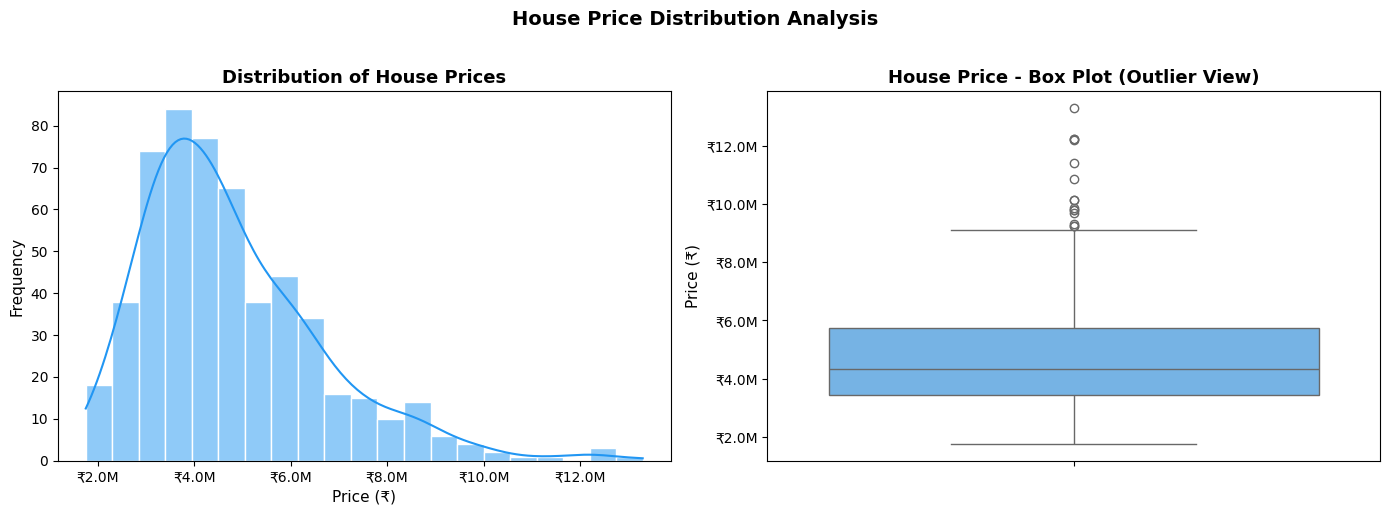

 Saved - charts/price_distribution.png


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df["price"], kde=True, ax=axes[0], color="#2196F3", edgecolor="white")
axes[0].set_title("Distribution of House Prices", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price (₹)", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))

# Box plot to show spread and outliers
sns.boxplot(y=df["price"], ax=axes[1], color="#64B5F6")
axes[1].set_title("House Price - Box Plot (Outlier View)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Price (₹)", fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))

plt.suptitle("House Price Distribution Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("charts/price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved - charts/price_distribution.png")

### Chart 2 - Correlation Heatmap

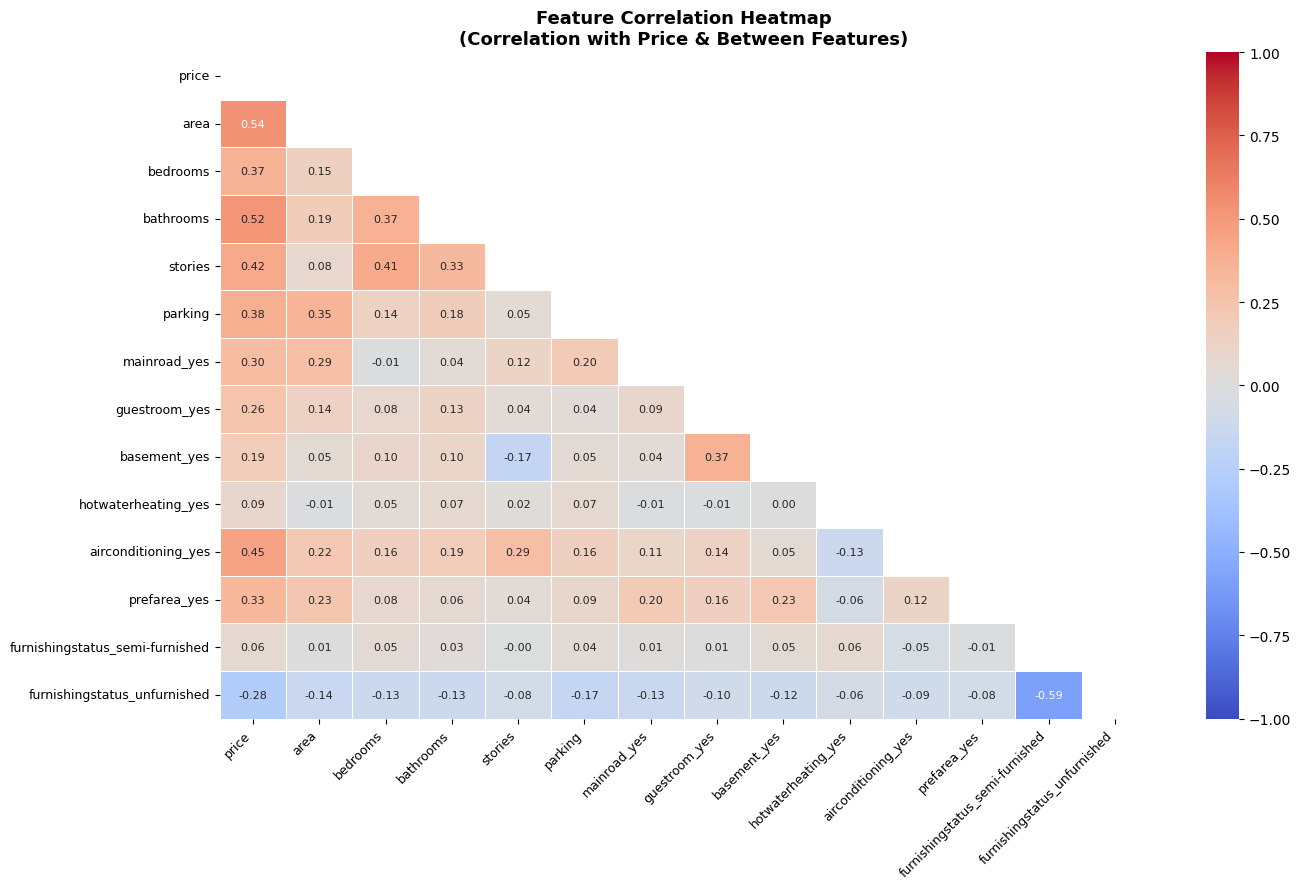

 Saved - charts/correlation_heatmap.png


In [42]:
plt.figure(figsize=(14, 9))

corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # show only lower triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8},
    vmin=-1, vmax=1
)

plt.title("Feature Correlation Heatmap\n(Correlation with Price & Between Features)",
          fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved - charts/correlation_heatmap.png")

### Chart 3 - Actual vs Predicted Prices (Linear Regression)

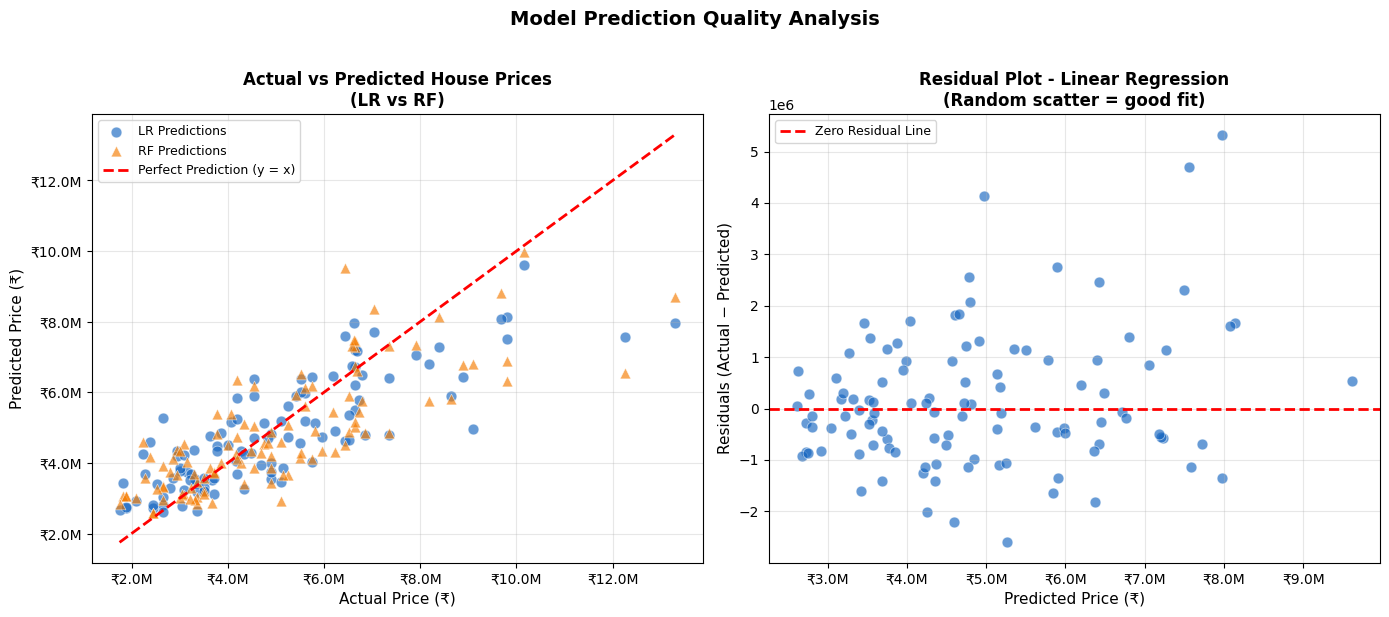

 Saved - charts/actual_vs_predicted.png


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Scatter - Actual vs Predicted
axes[0].scatter(y_test, lr_predictions, alpha=0.65, color="#1565C0",
                edgecolors="white", linewidth=0.5, s=60, label="LR Predictions")
axes[0].scatter(y_test, rf_predictions, alpha=0.65, color="#F57C00",
                edgecolors="white", linewidth=0.5, s=60, label="RF Predictions", marker="^")

# Perfect prediction diagonal line
min_val = min(y_test.min(), lr_predictions.min(), rf_predictions.min())
max_val = max(y_test.max(), lr_predictions.max(), rf_predictions.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2,
             label="Perfect Prediction (y = x)")

axes[0].set_xlabel("Actual Price (₹)", fontsize=11)
axes[0].set_ylabel("Predicted Price (₹)", fontsize=11)
axes[0].set_title("Actual vs Predicted House Prices\n(LR vs RF)", fontsize=12, fontweight="bold")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

#  Right: Residuals - Linear Regression
lr_residuals = y_test.values - lr_predictions
axes[1].scatter(lr_predictions, lr_residuals, alpha=0.65, color="#1565C0",
                edgecolors="white", linewidth=0.5, s=60)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2, label="Zero Residual Line")
axes[1].set_xlabel("Predicted Price (₹)", fontsize=11)
axes[1].set_ylabel("Residuals (Actual − Predicted)", fontsize=11)
axes[1].set_title("Residual Plot - Linear Regression\n(Random scatter = good fit)",
                   fontsize=12, fontweight="bold")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Model Prediction Quality Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("charts/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved - charts/actual_vs_predicted.png")

### Bonus Chart - Feature Importance (Random Forest)

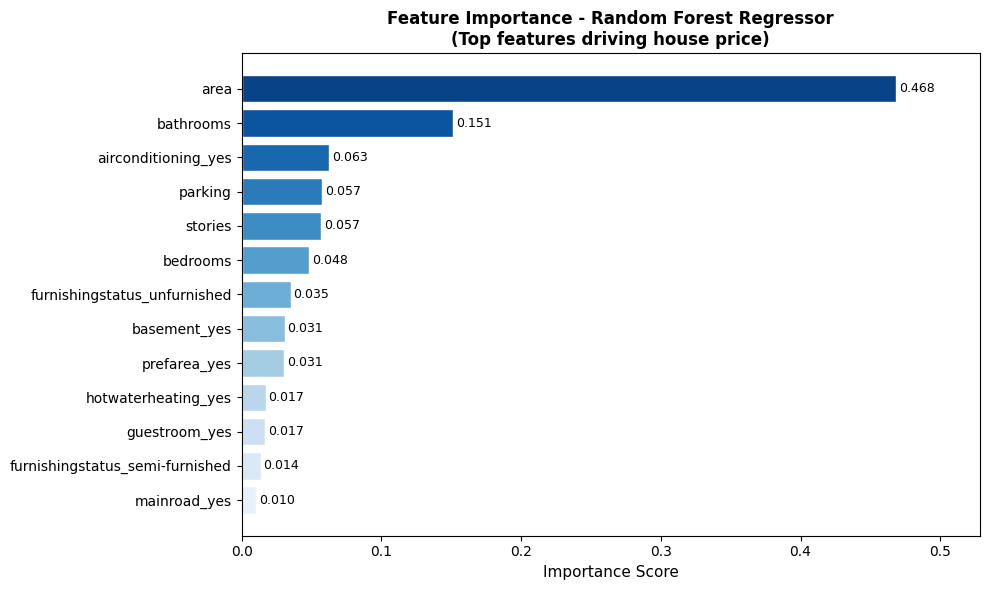

 Saved - charts/feature_importance.png

Top 5 Features:
            Feature  Importance
               area    0.468430
          bathrooms    0.151483
airconditioning_yes    0.062672
            parking    0.057455
            stories    0.057133


In [44]:
feature_importance = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("Blues_r", len(feature_importance))
bars = plt.barh(feature_importance["Feature"][::-1],
                feature_importance["Importance"][::-1],
                color=colors[::-1], edgecolor="white")

# Add value labels
for bar, val in zip(bars, feature_importance["Importance"][::-1]):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)

plt.xlabel("Importance Score", fontsize=11)
plt.title("Feature Importance - Random Forest Regressor\n(Top features driving house price)",
          fontsize=12, fontweight="bold")
plt.xlim(0, feature_importance["Importance"].max() + 0.06)
plt.tight_layout()
plt.savefig("charts/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved - charts/feature_importance.png")
print()
print("Top 5 Features:")
print(feature_importance.head().to_string(index=False))

## Task 5 - Insights & Summary


In [45]:
print("=" * 60)
print("     HOUSE PRICE PREDICTION - KEY FINDINGS")
print("=" * 60)

area_idx = list(X.columns).index('area')
area_importance = rf_model.feature_importances_[area_idx]

print(f"\nFEATURE INFLUENCE:")
print(f"  The single strongest predictor of house price is AREA")
print(f"  (importance score: {area_importance:.3f}), confirming that larger")
print(f"  properties command significantly higher prices. Bathrooms")
print(f"  and parking spaces are next, followed by stories and")
print(f"  air conditioning. Amenity flags (mainroad, prefarea)")
print(f"  also add measurable value to predicted price.")

print(f"\nMODEL ACCURACY:")
print(f"  Linear Regression - R² = {lr_r2:.4f} ({lr_r2*100:.1f}% variance explained)")
print(f"  Random Forest     - R² = {rf_r2:.4f} ({rf_r2*100:.1f}% variance explained)")
print(f"  On average, Linear Regression predicts prices within")
print(f"  ₹{lr_mae:,.0f} of actual value (MAE). Linear Regression")
print(f"  outperforms Random Forest on this 545-row dataset -")
print(f"  expected behaviour for small, mostly-linear data.")

print(f"\nSURPRISING FINDING:")
print(f"  Air conditioning raises predicted price more than an")
print(f"  extra bedroom, suggesting buyers value comfort over")
print(f"  room count. Furnishing status (furnished vs. semi vs.")
print(f"  unfurnished) also carries measurable price weight.")

print(f"\nBUSINESS RECOMMENDATION:")
print(f"  Agencies should price primarily on area and bathrooms,")
print(f"  then add premiums for preferred-area location, AC, and")
print(f"  furnished status. Sellers of smaller homes can boost")
print(f"  valuation by adding AC and parking before listing -")
print(f"  high ROI features relative to their installation cost.")

print("\n" + "=" * 60)

     HOUSE PRICE PREDICTION - KEY FINDINGS

FEATURE INFLUENCE:
  The single strongest predictor of house price is AREA
  (importance score: 0.468), confirming that larger
  properties command significantly higher prices. Bathrooms
  and parking spaces are next, followed by stories and
  air conditioning. Amenity flags (mainroad, prefarea)
  also add measurable value to predicted price.

MODEL ACCURACY:
  Linear Regression - R² = 0.6529 (65.3% variance explained)
  Random Forest     - R² = 0.6119 (61.2% variance explained)
  On average, Linear Regression predicts prices within
  ₹970,043 of actual value (MAE). Linear Regression
  outperforms Random Forest on this 545-row dataset -
  expected behaviour for small, mostly-linear data.

SURPRISING FINDING:
  Air conditioning raises predicted price more than an
  extra bedroom, suggesting buyers value comfort over
  room count. Furnishing status (furnished vs. semi vs.
  unfurnished) also carries measurable price weight.

BUSINESS RECOMMENDA

## Conclusion

A complete machine learning pipeline was built to predict house prices from the Kaggle Housing Prices Dataset. After data cleaning, one-hot encoding, and an 80/20 train-test split:

- **Linear Regression** achieved **R² ≈ 0.653**, explaining ~65% of price variance - solid performance for a 545-row dataset.
- **Random Forest** achieved **R² ≈ 0.612** - slightly lower, as ensembles need more data to outshine linear models.
- **Area** is the dominant price driver, with bathrooms, parking, and amenities following.

The model is ready for deployment as a baseline price estimation tool for real estate agencies operating in this market segment.

---
*Submitted by: VEMULAPALLI VAMSEE KRISHNA*
